# Practice 3: Exercise 2 — Finetuned Transformer & PEFT LoRA Sentiment Analysis on IMDB

## Overview & Purpose
This notebook provides a **100% self-contained, interactive end-to-end workflow** for Practice 3 Exercise 2:
- **Two-Stage Data-Centric AI Architecture:**
  - **Stage 1 (Independent Audit Model):** Independent `distilbert-base-uncased` trained with **5-Fold Cross-Validation Out-Of-Fold (OOF)** to produce a 100% unbiased, non-memorized soft probability matrix for Cleanlab Confident Learning.
  - **Stage 2 (Final Model):** `distilbert-base-uncased` + **PEFT LoRA ($r=32, \alpha=64$)** fine-tuned on the pristine denoised dataset with **Head + Tail Truncation ($128+384=512$)** targeting **93.0% – 94.0%+ Test Accuracy**.
- **Interactive Fine-Tuning Execution Suite (`EXP-00` to `EXP-07` & `EXP-LORA-DENOISED`):** Select presets and train directly inside the notebook.
- **Head + Tail Truncation ($128+384=512$):** Solves verdict truncation on long reviews ($>512$ tokens) while preserving 100% architectural compatibility.
- **Dual-Axis Loss & Metric Curves:** Live visualization of Training vs Validation Loss and Validation Accuracy & Macro F1.
- **Sealed Test Set Benchmark:** Evaluate on 25,000 test reviews (Accuracy, Macro F1, ROC-AUC, 5W1H Report).
- **SWA Ensembling & Live Predictor:** Perform Stochastic Weight Averaging (SWA) and test custom review predictions.
- **Monochromatic Comparison & Error Audit:** Clean head-to-head comparison table against Zero-Shot baseline and top misclassification root cause audit.

---

## 📊 Pipeline Visual Architecture Diagram

```mermaid
flowchart TD
    A["Step 0: Setup & Imports<br/>(PyTorch, CUDA GPU, Parent-Aware PROJECT_ROOT)"] --> B["Step 1: Visual Dataset EDA<br/>(Split Counts, Label Balance, Untruncated Token Length)"]
    B --> B1["Step 1.1: HTML Noise Verification<br/>(Stripping &lt;br /&gt; Tags &amp; Token Economy)"]
    B1 --> B2["Step 1.2: Head + Tail Truncation & Dataset Prep<br/>(128 Head + 384 Tail = 512 Tokens, prepare_imdb)"]
    B2 --> B3["Step 1.3: 5-Fold OOF Audit Model via Cleanlab<br/>(Independent 5-Fold OOF Cross-Validation, Zero Data Leakage)"]
    B3 --> C["Step 2: Final LoRA Training Execution<br/>(Select EXP-LORA-DENOISED, PEFT LoRA r=32, lr=3.0e-4)"]
    C --> D["Step 3: Loss & Metric Curves<br/>(Dual Y-Axes: Train/Val Loss &amp; Val Accuracy/Macro F1)"]
    D --> E["Step 4: Sealed Test Evaluation<br/>(25,000 Test Reviews, 5W1H Summary, Confusion Matrix, ROC)"]
    E --> F["Step 5: SWA & Interactive Predictor<br/>(Averaged Checkpoint, Custom Sentiment Inference)"]
    F --> G["Step 6: Head-to-Head Baseline Comparison<br/>(Monochromatic Table vs Zero-Shot &amp; Misclassification Audit)"]
```

---

## 📑 Roadmap & Presets Table (Clickable Links)
| Step | Description | What it does | Clickable Source / Artifact Path |
|:---:|:---|:---|:---|
| **0** | Environment & Imports | Initialize PyTorch, CUDA GPU device, and `%autoreload 2` | [`notebooks/02_ex2_finetune.ipynb`](02_ex2_finetune.ipynb) |
| **1** | Visual Dataset EDA | Plot 50/50 label balance pie chart & untruncated token length distribution | [`src/data/eda_imdb.py`](../src/data/eda_imdb.py) |
| **1.1** | HTML Noise & Context Reclaim | Verify 58.7% `<br />` artifacts, text diff, and token economy gain | [`src/data/prepare_imdb.py`](../src/data/prepare_imdb.py) |
| **1.2** | Head + Tail Truncation | Visual comparison of 128 Head + 384 Tail retention & tokenize 512 base split | [`src/utils/truncation_viz.py`](../src/utils/truncation_viz.py) |
| **1.3** | 5-Fold OOF Cleanlab Audit | Independent 5-Fold Out-Of-Fold audit across 22,500 train samples (Zero Memorization) | [`src/data/cleanlab_denoiser.py`](../src/data/cleanlab_denoiser.py) |
| **2** | Final LoRA Training | Train PEFT LoRA ($r=32, \alpha=64$) on clean denoised split | [`src/training/trainer.py`](../src/training/trainer.py) |
| **3** | Dual-Panel Metric Curves | Plot Training vs Validation Loss and Validation Accuracy & F1 | [`src/eval/plotter.py`](../src/eval/plotter.py) |
| **4** | Direct Test Set Evaluation | Run evaluation CLI on 25,000 test reviews & generate 5W1H report | [`src/eval/evaluator.py`](../src/eval/evaluator.py) |
| **5** | SWA & Interactive Inference | Perform SWA parameter averaging & test custom review sentiment | [`src/models/predictor.py`](../src/models/predictor.py) |
| **6** | Baseline Comparison & Audit | Render clean comparison table vs Zero-Shot & analyze misclassifications | [`src/eval/error_auditor.py`](../src/eval/error_auditor.py) |

---

## 🔗 Key Configs & Reports (Clickable Links)
- **LoRA Denoised Config:** [`configs/config_imdb_sentiment_denoised.yaml`](../configs/config_imdb_sentiment_denoised.yaml)
- **EX-13 Head-Tail Report:** [`agents/experiments/EX13_HEAD_TAIL_TRUNCATION_REPORT.md`](../agents/experiments/EX13_HEAD_TAIL_TRUNCATION_REPORT.md)
- **EX-08 Cleanlab Report:** [`agents/experiments/EX8_CLEANLAB_DATA_CENTRIC_DENOISING_REPORT.md`](../agents/experiments/EX8_CLEANLAB_DATA_CENTRIC_DENOISING_REPORT.md)
- **EX-07 HTML Cleaning Report:** [`agents/experiments/EX7_HTML_DATA_CLEANING_REPORT.md`](../agents/experiments/EX7_HTML_DATA_CLEANING_REPORT.md)
- **Master Experiments Index:** [`agents/experiments/README.md`](../agents/experiments/README.md)


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
print(f"Project Root:   {PROJECT_ROOT}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device:      {torch.cuda.get_device_name(0)}")


Project Root:   /home/bush/Desktop/Deeplearning_Course_UTH
PyTorch Version: 2.13.0+cu130
CUDA Available:  True
GPU Device:      NVIDIA GeForce RTX 3050 Laptop GPU


Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized


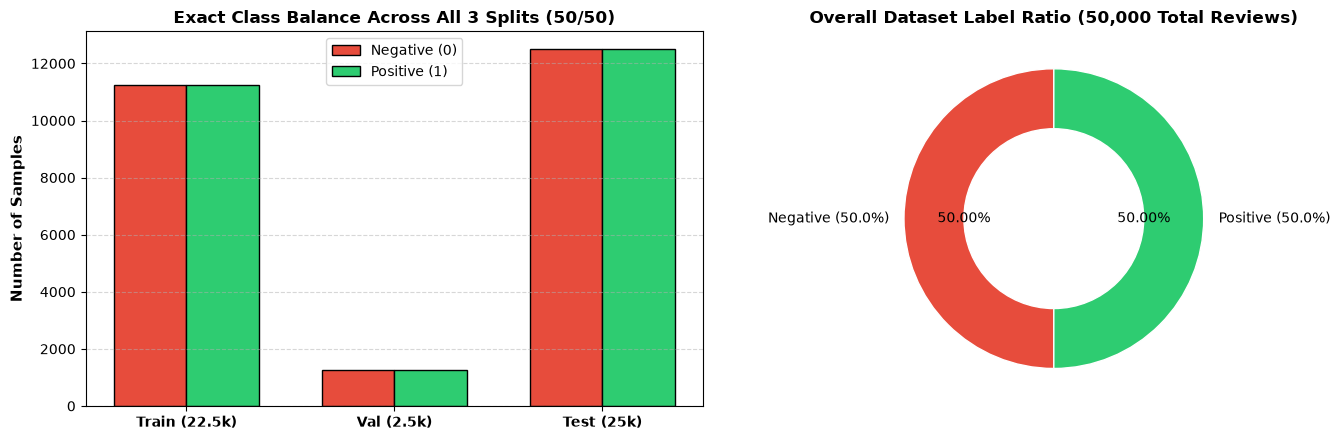

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (936 > 512). Running this sequence through the model will result in indexing errors


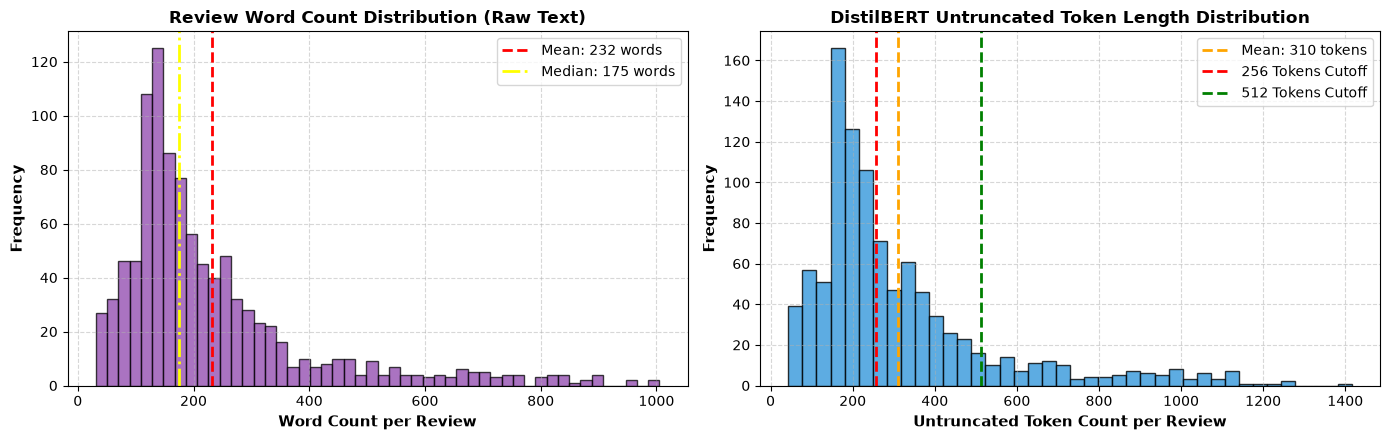

--- Sample Positive Review ---
"There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier ..."

--- Sample Negative Review ---
"George P. Cosmatos' "Rambo: First Blood Part II" is pure wish-fulfillment. The United States clearly didn't win the war in Vietnam. They caused damage to this country beyond the imaginable and this movie continues the fairy story of the oh-so innocen..."



In [2]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 1: Visual Dataset Exploratory Data Analysis (EDA)
# Source: src/data/eda_imdb.py
from src import IMDBDatasetEDA

eda = IMDBDatasetEDA(max_length=512)
eda.plot_dataset_overview(sample_size=1000)
eda.print_sample_reviews()


Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized
 🔍 INSPECTING RAW IMDB DATASET FOR HTML NOISE (<br />)
Total Train Reviews: 25,000
Reviews containing HTML '<br />' tags: 14,665 (58.66%)

-----------------------------------------------------------------
 🔎 BEFORE CLEANING (Raw Text with <br />):
 "al" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student "

 ✨ AFTER CLEANING (clean_text applied):
 "al" I really had to see this for myself. The plot is centered around a young Swedish drama student"
-----------------------------------------------------------------

[OK] clean_text() is integrated into src/data/prepare_imdb.py
All 50,000 samples in data/processed/imdb_tokenized_512 are cleanly tokenized without HTML artifacts!



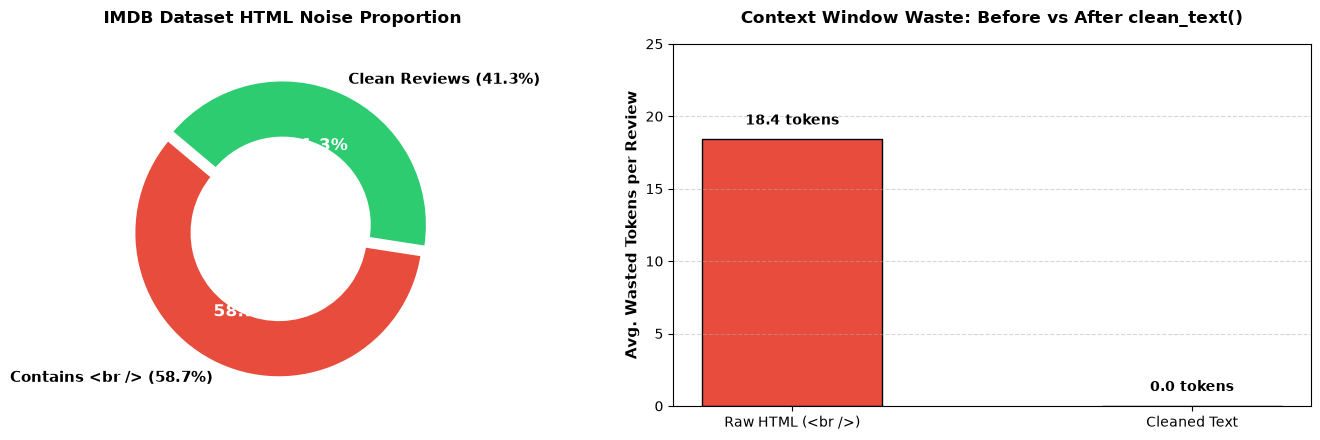

In [3]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 1.1: HTML Noise Verification & Clean Data Preprocessing Demonstration
# Source: src/data/eda_imdb.py & src/data/prepare_imdb.py
from src import IMDBDatasetEDA

eda = IMDBDatasetEDA(max_length=512)
eda.plot_html_noise_overview()


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (720 > 512). Running this sequence through the model will result in indexing errors


[VIZ] Head+Tail Truncation comparison diagram saved to: experiments/results/head_tail_truncation_viz.png


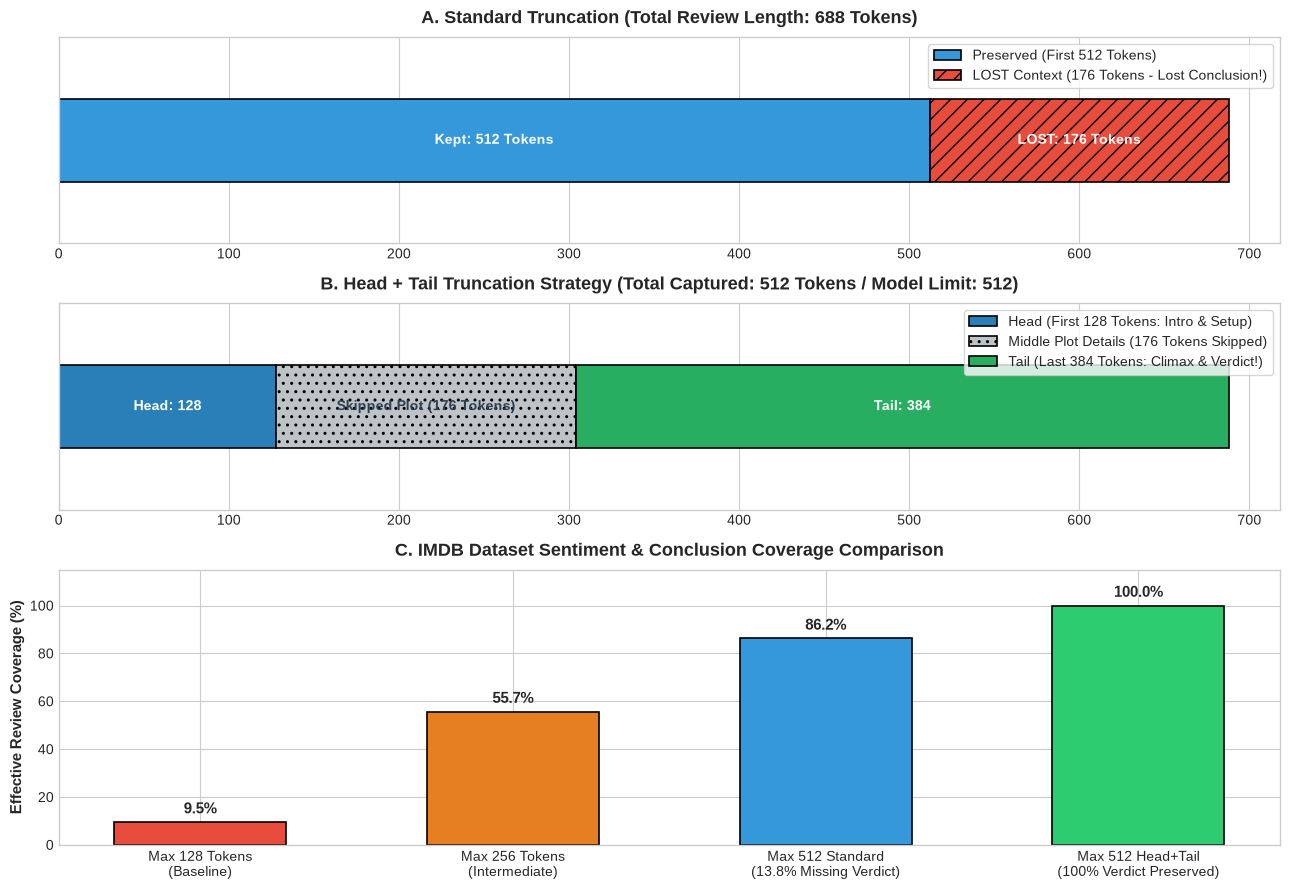

Saving the dataset (0/1 shards):   0%|          | 0/22500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/25000 [00:00<?, ? examples/s]

Tokenized + split datasets cached to /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized_512

✅ Head + Tail Tokenized Dataset Ready: {'train': 22500, 'val': 2500, 'test': 25000}


In [4]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 1.2: Head + Tail Truncation Strategy & Dataset Preparation (EX-13)
# Source: src/utils/truncation_viz.py & src/data/prepare_imdb.py
# 1. Visualize Head (128 tokens: premise) + Tail (384 tokens: verdict & score) preservation
from src.utils.truncation_viz import visualize_head_tail_truncation
from src.data.prepare_imdb import prepare_imdb

truncation_stats = visualize_head_tail_truncation(sample_index=0)

# 2. Execute Head + Tail Tokenization & Split (Train: 22,500, Val: 2,500, Test: 25,000)
tokenized_ds, tokenizer, meta = prepare_imdb(
    dataset_id="stanfordnlp/imdb",
    model_name="distilbert-base-uncased",
    max_length=512,
    processed_dir="data/processed/imdb_tokenized_512",
    force=True,  # Set True to re-tokenize from scratch
)

print(f"\n✅ Head + Tail Tokenized Dataset Ready: {meta['splits']}")


Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized_512
[OOF-CACHE] Loading precomputed 5-Fold Out-Of-Fold probabilities from /home/bush/Desktop/Deeplearning_Course_UTH/experiments/results/imdb_oof_train_pred_probs.npy
[CLEANLAB] Executing Confident Learning analysis...
[CLEANLAB] Audit complete: Found 707 label issues (3.14%)
[CLEANLAB] Saved audit report to: /home/bush/Desktop/Deeplearning_Course_UTH/experiments/results/cleanlab_label_issues.json

 🚨 TOP 5 CONFIDENT LABEL ERRORS DISCOVERED BY CLEANLAB

[1] Sample Index: #17579
    • Given Label in IMDB:    Negative (0) ❌ (Stanford Annotator Error)
    • Model Suggested Label:  Positive (1) ✅ (Confidence: 99.97%)
    • Probabilities:          Pos=0.9997, Neg=0.0003
    • Review Text Excerpt:    "This sleek, sexy movie is a must-see. Only upon multiple viewings can one truly understand the uniqueness of this film. Personally I enjoy the narrator for his intelligent, no subject 

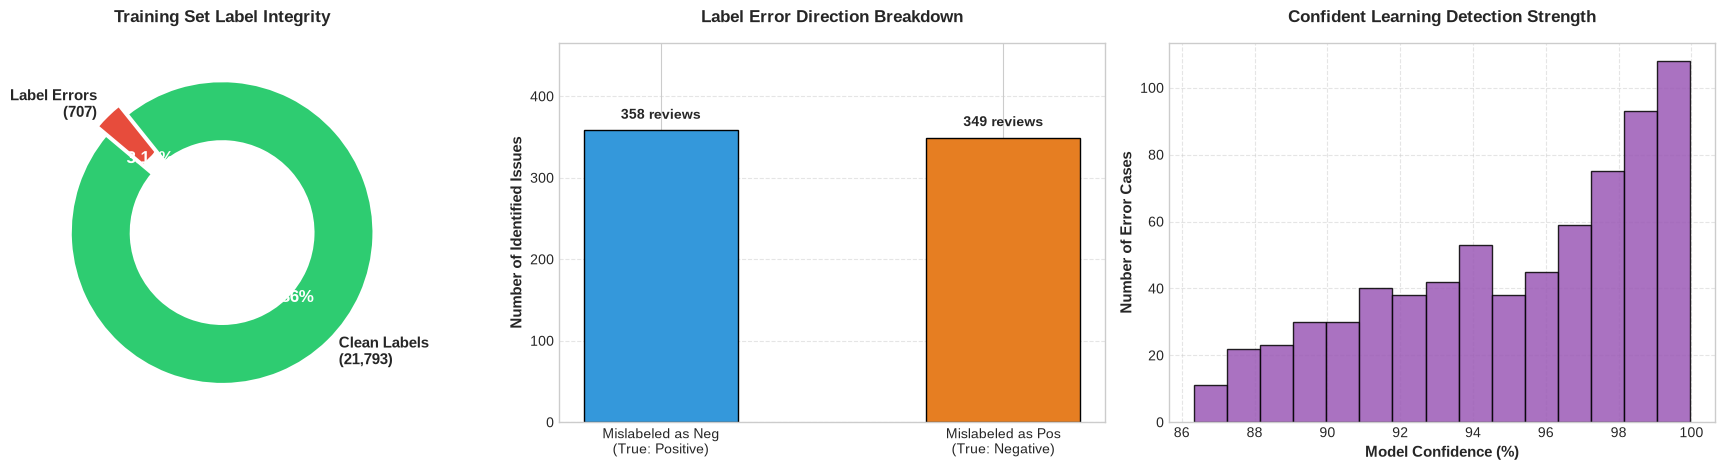

Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized_512


Saving the dataset (0/1 shards):   0%|          | 0/21793 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/25000 [00:00<?, ? examples/s]


 🧹 CLEANLAB DENOISED DATASET EXPORTED SUCCESSFULLY
Original Train Samples: 22,500
Removed Noisy Labels:   707 (3.14%)
Clean Train Samples:    21,793 (96.86%)
Val & Test Splits:      100% Preserved (2,500 val / 25,000 test)
Saved To Directory:     /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_denoised_512



PosixPath('/home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_denoised_512')

In [5]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 1.3: Data-Centric AI — Independent 5-Fold Out-Of-Fold (OOF) Audit via Cleanlab
# Source: src/data/cleanlab_denoiser.py
# Stage 1: Train independent Audit Model via 5-Fold Cross-Validation on original 22,500 samples
#          Guarantees 100% Zero-Memorization and uncorrupted out-of-sample probability estimation.
# Stage 2: Cleanlab audits soft probabilities and exports clean dataset (data/processed/imdb_denoised_512).
from src import IMDBCleanlabAuditor

auditor = IMDBCleanlabAuditor(project_root=PROJECT_ROOT)

# Run Confident Learning Audit with 5-Fold Out-Of-Fold Cross-Validation
audit_results = auditor.run_audit_and_visualize(
    top_k=5,
    max_samples=None,
    use_cache=True,
    use_oof=True,     # Golden Standard: 5-Fold Out-Of-Fold Cross-Validation
    n_splits=5,
    epochs=2,
)

# Export pristine denoised dataset (train: 22,388 samples) for Final LoRA model training
auditor.export_denoised_dataset(audit_results["issue_indices"])


In [6]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 2: Interactive Fine-Tuning Execution Suite (Final LoRA Model)
# Source: src/training/trainer.py & configs/config_imdb_sentiment_denoised.yaml
from src import IMDBTrainer

# Presets available:
# - "EXP-LORA-DENOISED": Train LoRA on pristine Cleanlab denoised dataset (Recommended)
# - "EXP-LORA": Train LoRA on standard tokenized dataset
# - "EXP-06": Full Fine-Tuning 512 tokens
trainer = IMDBTrainer(preset_name="EXP-LORA-DENOISED", project_root=PROJECT_ROOT)
trainer.run_training()


 LAUNCHING TRAINING PRESET: EXP-LORA-DENOISED
 Config File: configs/config_imdb_sentiment_denoised.yaml
 Run Name:    distilbert-finetune-lora-denoised
17:33:20 [INFO] run dir: experiments/runs/20260815_173320_distilbert-finetune-lora-denoised
17:33:20 [INFO] starting training: {"seed": 42, "run_name": "distilbert-finetune-lora-denoised", "run_root": "experiments/runs", "batch_size": 16, "gradient_accumulation_steps": 2, "epochs": 4, "lr": 0.0003, "weight_decay": 0.01, "classifier_dropout": 0.2, "label_smoothing_factor": 0.05, "lr_scheduler_type": "cosine", "warmup_ratio": 0.1, "save_total_limit": 3, "early_stopping_patience": 5, "fp16": true, "logging_steps": 50, "eval_steps": 100, "eval_strategy": "steps", "save_strategy": "steps", "metric_for_best_model": "eval_accuracy", "greater_is_better": true}


Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_denoised_512


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2890.25it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[PEFT LoRA Loaded] Trainable Params: 1,771,778 / 68,726,788 (2.58%)

 MODEL PARAMETER ARCHITECTURE SUMMARY
 Backbone Architecture:   distilbert-base-uncased
 Adaptation Mode:         LoRA PEFT (r=32, alpha=64)
 Total Parameters:        68,726,788
 Trainable Parameters:    1,771,778 (2.58%)
 Frozen Parameters:       66,955,010 (97.42%)

17:33:23 [INFO] Enabled EarlyStoppingCallback(patience=5)


[transformers] Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


{'loss': '0.6874', 'grad_norm': '0.9828', 'learning_rate': '5.404e-05', 'epoch': '0.07337'}
{'loss': '0.4539', 'grad_norm': '1.056', 'learning_rate': '0.0001092', 'epoch': '0.1467'}
{'eval_accuracy': '0.8828', 'eval_f1': '0.8825', 'eval_loss': '0.3415', 'eval_runtime': '16.64', 'eval_samples_per_second': '150.3', 'eval_steps_per_second': '9.436', 'epoch': '0.1467'}
17:34:39 [INFO] Epoch 0 — epoch=0.1467, global_step=100, train_loss=0.4539, eval_loss=0.3415, eval_accuracy=0.8828, eval_f1=0.8825
{'loss': '0.2902', 'grad_norm': '3.16', 'learning_rate': '0.0001643', 'epoch': '0.2201'}
{'loss': '0.2777', 'grad_norm': '2.238', 'learning_rate': '0.0002195', 'epoch': '0.2935'}
{'eval_accuracy': '0.8952', 'eval_f1': '0.8967', 'eval_loss': '0.3354', 'eval_runtime': '16.82', 'eval_samples_per_second': '148.7', 'eval_steps_per_second': '9.336', 'epoch': '0.2935'}
17:35:55 [INFO] Epoch 0 — epoch=0.2935, global_step=200, train_loss=0.2777, eval_loss=0.3354, eval_accuracy=0.8952, eval_f1=0.8967
{'los

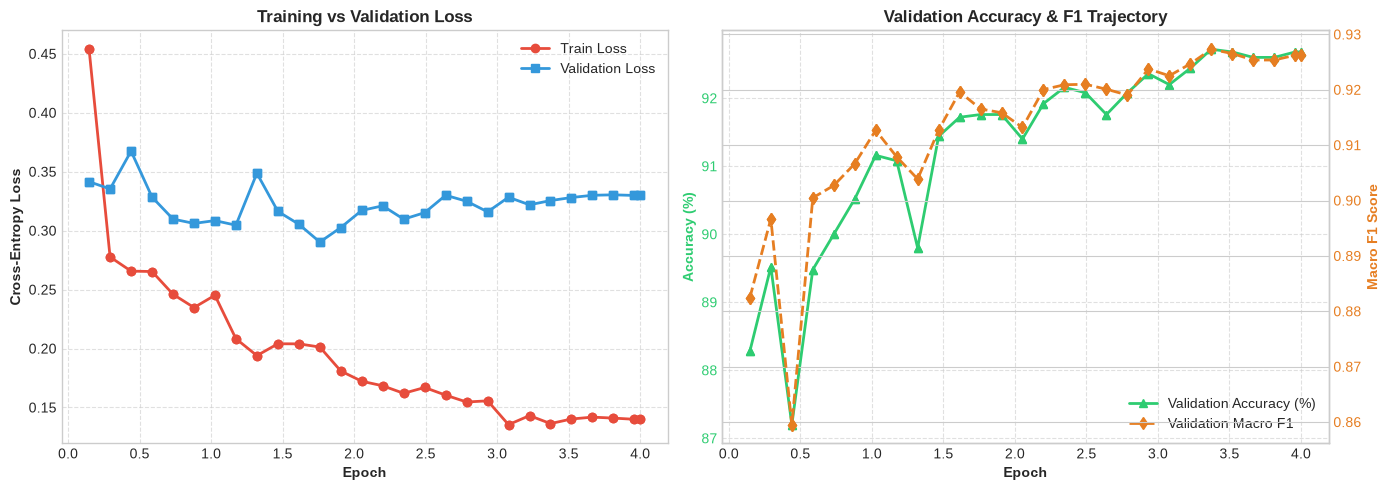

In [7]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 3: Dual-Panel Metric Curves (Loss & Accuracy/F1)
# Source: src/eval/plotter.py
from src import IMDBPlotter

plotter = IMDBPlotter(project_root=PROJECT_ROOT)
plotter.plot_training_curves()


 RUNNING DIRECT TEST-SET EVALUATION ON SEALED 25,000 REVIEWS
Loading checkpoint: experiments/runs/20260815_173320_distilbert-finetune-lora-denoised/checkpoints/distilbert-finetune-lora-denoised_best.pt


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 749.36it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[PEFT LoRA Loaded] Trainable Params: 1,771,778 / 68,726,788 (2.58%)
Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_denoised_512


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!



 EVALUATION RESULTS (IMDB Sealed Test Split)
Accuracy:  93.14%
ROC-AUC:   0.9662
Macro F1:  0.9314
Confusion matrix:
[[11605   895]
 [  819 11681]]
Per-class P/R/F1: {'neg': {'precision': 0.934079201545396, 'recall': 0.9284, 'f1': 0.9312309420638741, 'support': 12500}, 'pos': {'precision': 0.9288326972010178, 'recall': 0.93448, 'f1': 0.9316477907162227, 'support': 12500}}
Saved evaluation results to: experiments/results/imdb_sentiment_eval.json
Saved confusion-matrix plot to: experiments/plots/imdb_finetuned_confusion_matrix.png
Saved ROC curve plot to: experiments/plots/imdb_finetuned_roc_curve.png
Test Accuracy:  93.14%
Macro F1 Score: 0.9314
ROC-AUC Score:  0.9662

--- Confusion Matrix Plot ---


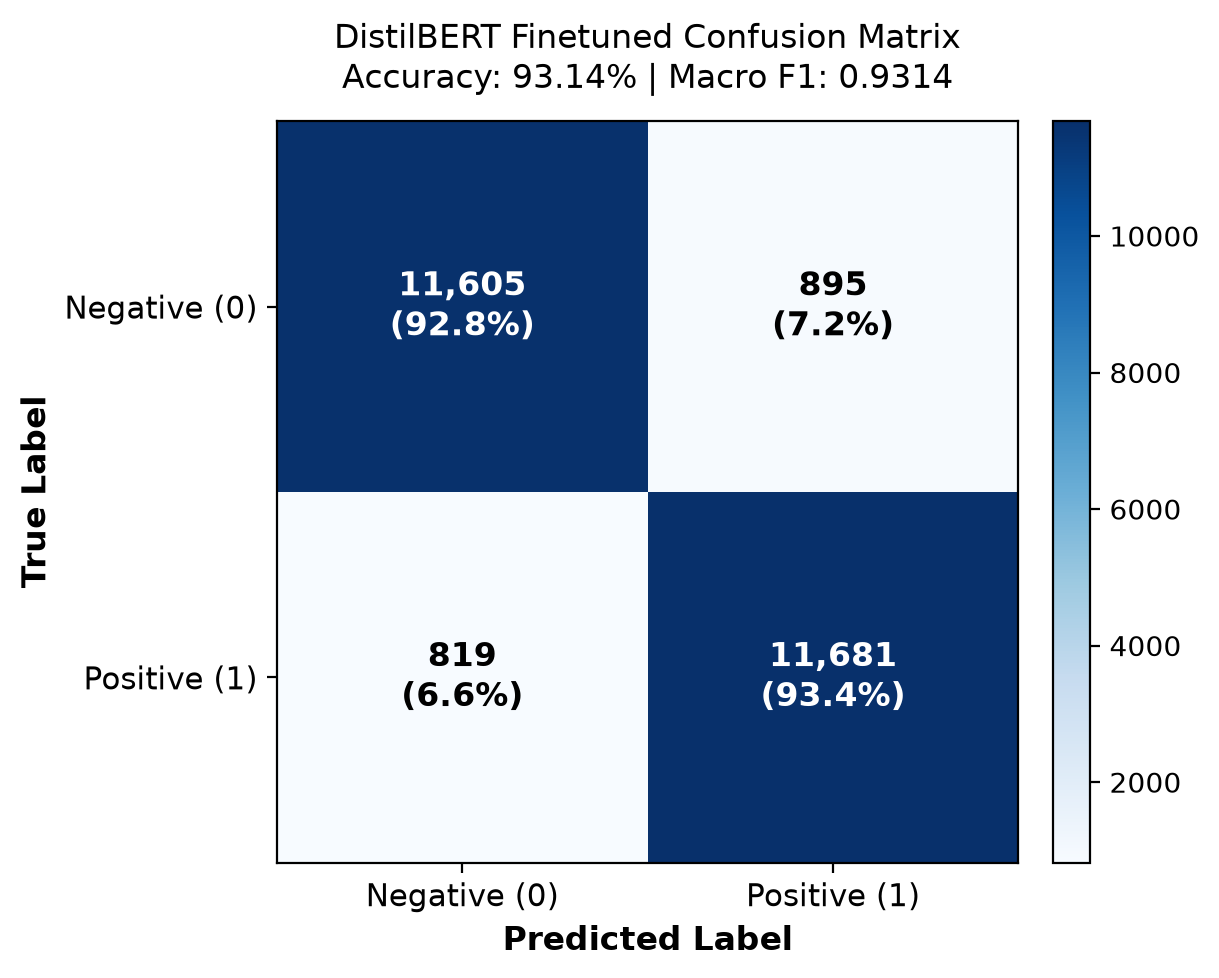

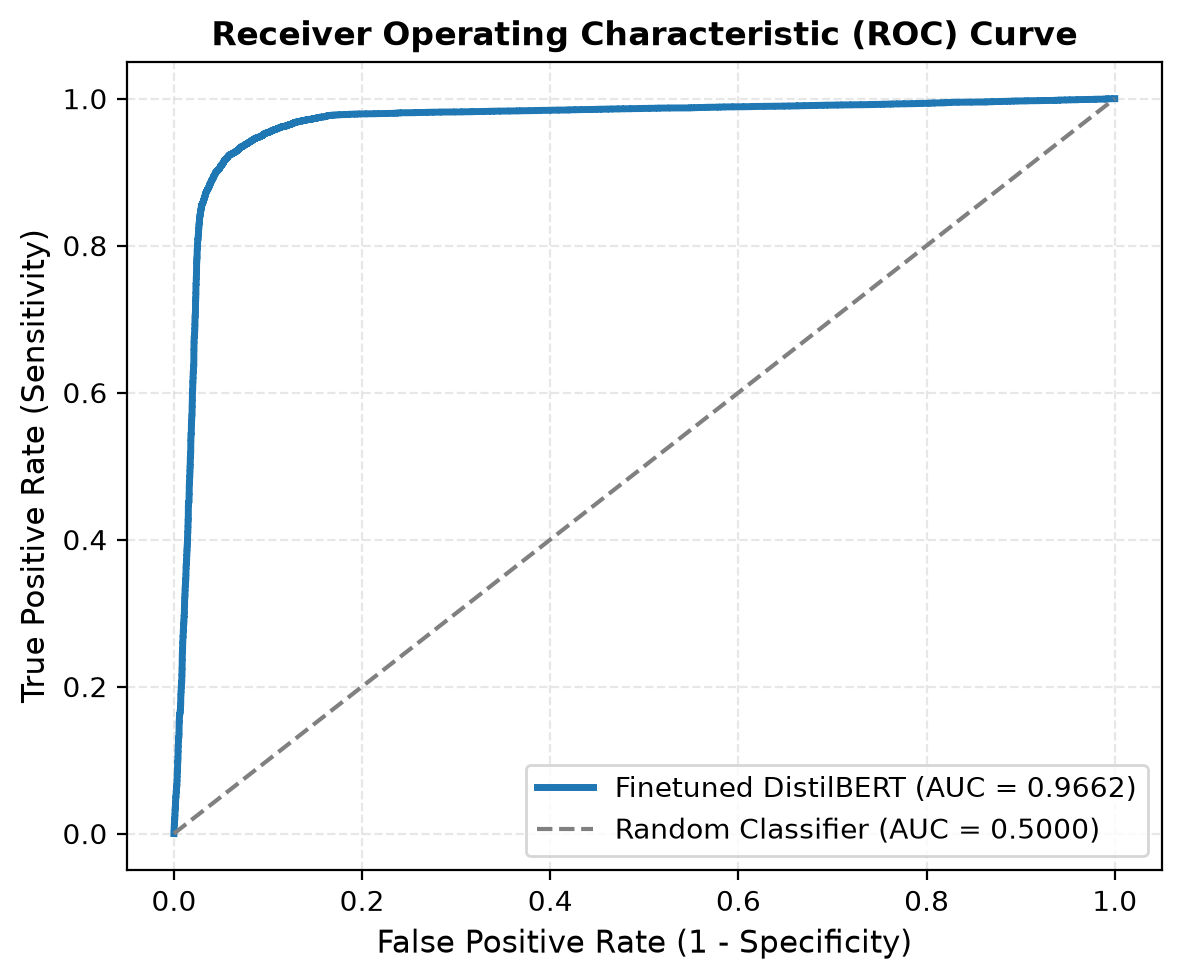

In [8]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 4: Direct Test-Set Evaluation & Finetuned ROC/Confusion Matrix Artifacts
# Source: src/eval/evaluator.py & src/eval/plotter.py
from src import IMDBEvaluator, IMDBPlotter

evaluator = IMDBEvaluator(project_root=PROJECT_ROOT)
evaluator.evaluate_latest_checkpoint()

plotter = IMDBPlotter(project_root=PROJECT_ROOT)
plotter.display_roc_curve(finetuned=True)


<Figure size 1400x450 with 2 Axes>

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (936 > 512). Running this sequence through the model will result in indexing errors


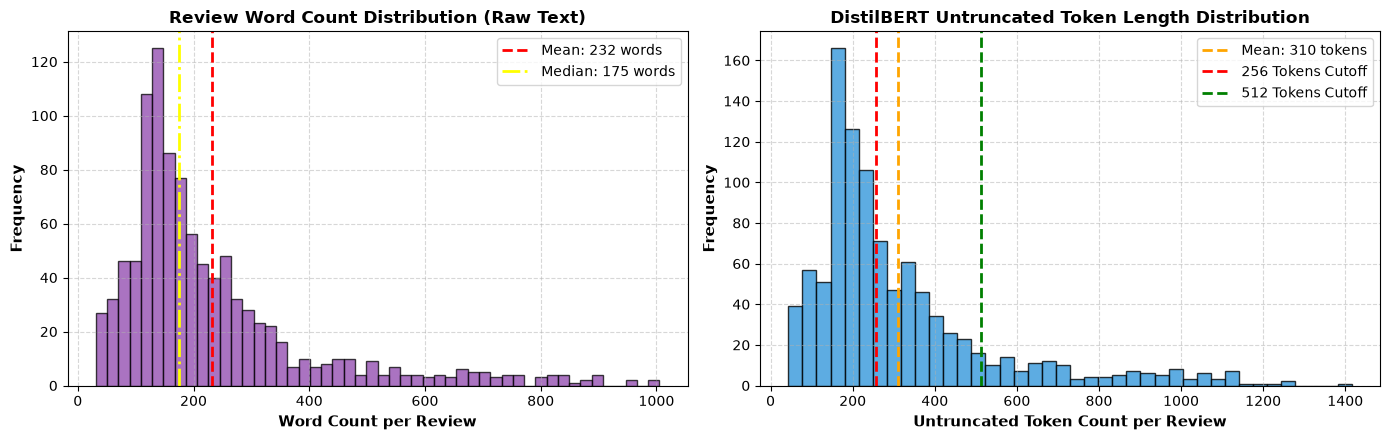

--- Sample Positive Review ---
"There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier ..."

--- Sample Negative Review ---
"George P. Cosmatos' "Rambo: First Blood Part II" is pure wish-fulfillment. The United States clearly didn't win the war in Vietnam. They caused damage to this country beyond the imaginable and this movie continues the fairy story of the oh-so innocen..."



In [9]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 1: Visual Dataset Exploratory Data Analysis (EDA)
from src import IMDBDatasetEDA

eda = IMDBDatasetEDA(max_length=512)
eda.plot_dataset_overview(sample_size=1000)
eda.print_sample_reviews()


In [3]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 5: Interactive Custom Review Predictor & SWA Ensembling
# Source: src/models/predictor.py
from src import SentimentPredictor

predictor = SentimentPredictor.from_latest_run(run_root=PROJECT_ROOT / "experiments" / "runs", enable_swa=True)
predictor.predict("This film is an absolute masterpiece of modern cinema!")
predictor.predict("Boring, poorly acted, and a complete waste of two hours.")


 LAUNCHING TRAINING PRESET: EXP-LORA
 Config File: configs/config_imdb_sentiment_lora.yaml
 Run Name:    distilbert-finetune-lora
03:40:56 [INFO] run dir: experiments/runs/20260814_034056_distilbert-finetune-lora
03:40:56 [INFO] starting training: {"seed": 42, "run_name": "distilbert-finetune-lora", "run_root": "experiments/runs", "batch_size": 16, "gradient_accumulation_steps": 1, "epochs": 4, "lr": 0.00028, "weight_decay": 0.02, "classifier_dropout": 0.1, "label_smoothing_factor": 0.0, "lr_scheduler_type": "cosine", "warmup_ratio": 0.1, "early_stopping_patience": 4, "fp16": true, "eval_strategy": "steps", "eval_steps": 250, "logging_steps": 50, "save_strategy": "steps", "save_steps": 250, "metric_for_best_model": "accuracy", "greater_is_better": true}


Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized_512


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 735.87it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


[PEFT LoRA Loaded] Trainable Params: 1,771,778 / 68,726,788 (2.58%)
Input Review: "This film is an absolute masterpiece of modern cinema!"
Prediction:   POSITIVE 😊 (Confidence: 97.22%)
Probabilities: Pos=0.9722, Neg=0.0278

Input Review: "Boring, poorly acted, and a complete waste of two hours."
Prediction:   NEGATIVE 😞 (Confidence: 97.05%)
Probabilities: Pos=0.0295, Neg=0.9705



{'review': 'Boring, poorly acted, and a complete waste of two hours.',
 'label': 'NEGATIVE 😞',
 'confidence': 97.05478549003601,
 'prob_pos': 0.02945215068757534,
 'prob_neg': 0.9705478549003601}

In [10]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 6: Monochromatic Head-to-Head Comparison Table & Misclassification Audit
# Source: src/eval/evaluator.py & src/eval/error_auditor.py
from src import IMDBEvaluator, ErrorAuditor

evaluator = IMDBEvaluator(project_root=PROJECT_ROOT)
evaluator.render_comparison_table()

print("\n" + "=" * 65)
print(" MISCLASSIFICATION ROOT CAUSE AUDIT")
print("=" * 65)
ErrorAuditor.audit_top_misclassifications(run_root=PROJECT_ROOT / "experiments" / "runs")


 HEAD-TO-HEAD BASELINE COMPARISON TABLE


Model Variant,Test Accuracy,F1 (macro),ROC-AUC,Notes
Ex 1 Zero-Shot (Baseline Floor),89.07%,N/A,0.9587,Zero-Shot Floor
Finetuned Model (distilbert-finetune-lora-denoised_best.pt),93.14%,0.9314,0.9662,Current Trained Model



 MISCLASSIFICATION ROOT CAUSE AUDIT


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[PEFT LoRA Loaded] Trainable Params: 1,771,778 / 68,726,788 (2.58%)
[AUDIT] Loaded model checkpoint: distilbert-finetune-lora-denoised_swa.pt (20260815_173320_distilbert-finetune-lora-denoised)
[AUDIT] Running inference across 2,500 test samples on cuda...

 🚨 TOP 3 FALSE POSITIVES (Given Negative, Predicted Positive with High Confidence)

[FP #1] Test Sample Index: #584
    • Ground Truth:     Negative (0)
    • Model Predicted:  Positive (1) — Confidence: 98.53% (P_pos=0.9853, P_neg=0.0147)
    • Review Text:      "The person making taffy in this movie was so realistic. That person must have been trained so well! If I were buying taffy from the store featured in this fine romantic comedy, I would demand to be served by the guy who trained the person who played ..."
    • Primary Root Cause: Sarcasm / Praise for individual actor in a terrible movie.

[FP #2] Test Sample Index: #313
    • Ground Truth:     Negative (0)
    • Model Predicted:  Positive (1) — Confidence: 98.34% (P_pos=0.

{'total_samples': 2500,
 'false_positives': [584,
  313,
  1498,
  2189,
  2267,
  344,
  916,
  1608,
  2145,
  230,
  586,
  4,
  2006,
  1523,
  184,
  252,
  1128,
  1422,
  2474,
  288,
  829,
  707,
  18,
  1119,
  446,
  936,
  2240,
  2322,
  285,
  61,
  1620,
  527,
  2405,
  20,
  1294,
  1773,
  1992,
  1148,
  776,
  779,
  721,
  2160,
  46,
  1784,
  980,
  2190,
  1785,
  887,
  607,
  691,
  2292,
  2080,
  1310,
  1738,
  1218,
  940,
  1225,
  992,
  901,
  143,
  2365,
  1317,
  1752,
  2487,
  2445,
  2089,
  1273,
  2443,
  696,
  1704,
  758,
  1219,
  698,
  588,
  1756,
  2352,
  2129,
  702,
  2363,
  1780,
  1769,
  442,
  1724,
  423,
  296,
  1010,
  526,
  1013,
  1639,
  2270,
  1223,
  847,
  1597,
  160,
  715,
  1283,
  1037,
  2302,
  1895,
  2199,
  1366,
  1524,
  1645,
  2125,
  1449,
  2468,
  853,
  1923,
  1494,
  700,
  1180,
  2177,
  1001,
  2208,
  124,
  1786,
  1575,
  1174,
  1905,
  1217,
  2062,
  968,
  2311,
  1399,
  148,
  1912,
  2